In [20]:
!pip install kagglehub

In [21]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # scikit-learn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score

In [22]:
# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

dataset = pd.read_csv(f'{path}/Housing.csv')

categorical_cols = dataset.select_dtypes(include=['object']).columns # dtype - Selecting Data Type

integer_cols = dataset.select_dtypes(include=['int64']).columns

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


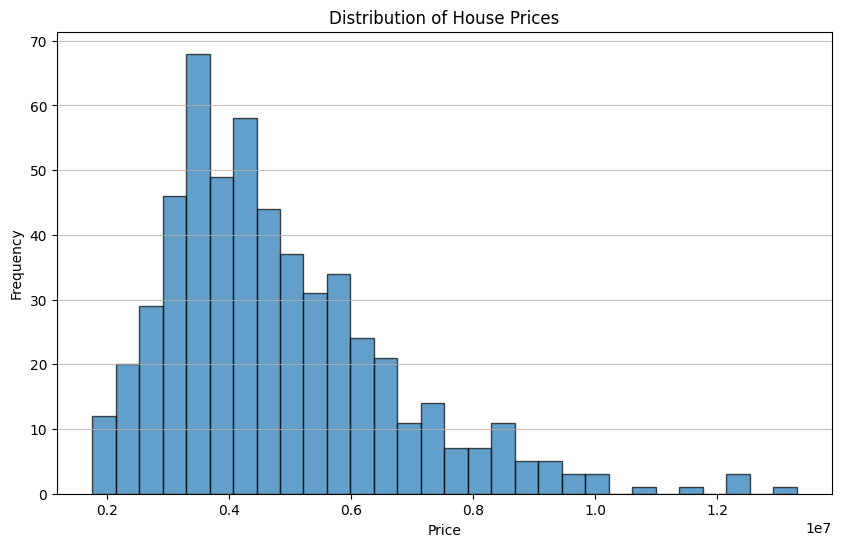

In [23]:
plt.figure(figsize=(10, 6)) # Figure Size
plt.hist(dataset['price'], bins=30, edgecolor='k', alpha=0.7) #
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [24]:
np.random.seed(42)

y = dataset['price'] # Target
X = dataset[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
             'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']] # 12 Features (Input)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42) # f(X,y, test_size, rs)

categorical_cols = X_train.select_dtypes(include=['object']).columns
integer_cols = X_train.select_dtypes(include=['int64']).columns

In [25]:
X_train_cat = X_train[categorical_cols]
X_train_int = X_train[integer_cols]

X_test_cat = X_test[categorical_cols]
X_test_int = X_test[integer_cols]

In [26]:
encoder=OneHotEncoder(sparse_output=False,drop='first') # Category - numbers ONE HOT ENCODING

X_train_encoded=encoder.fit_transform(X_train_cat) # fit_transform (compute) , transform (inference)

X_test_encoded=encoder.transform(X_test_cat)

X_train_encoded[0]

array([1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

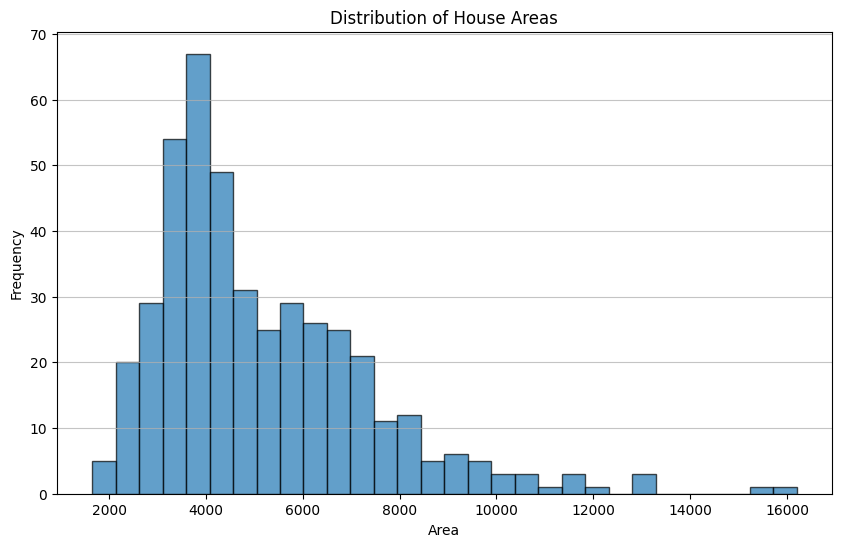

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(X_train_int['area'], bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of House Areas')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [28]:
standard=StandardScaler() # z= (X-mean)/std mean=0, std=1

X_train_scaled=standard.fit_transform(X_train_int) # Compute - Mean, STD -> 0,1

X_test_scaled=standard.transform(X_test_int)# Mean, STD -> 0,1

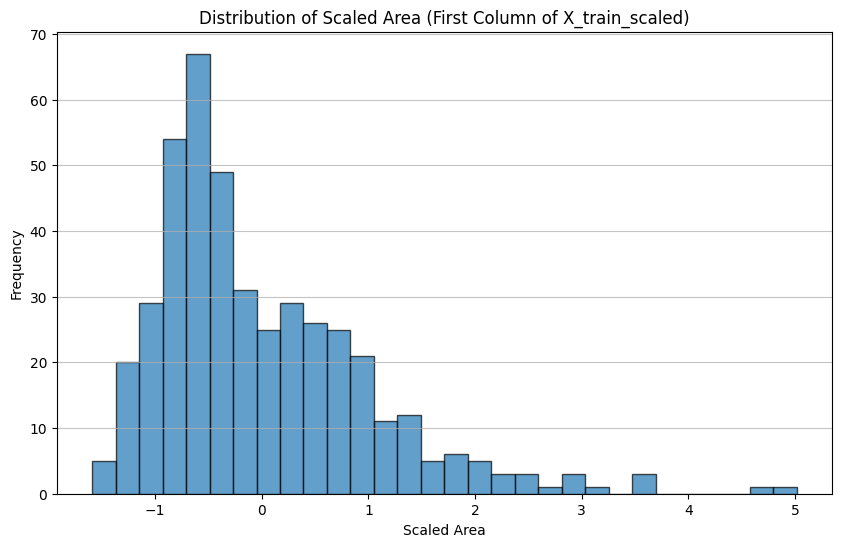

In [29]:
plt.figure(figsize=(10, 6))
plt.hist(X_train_scaled[:, 0], bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Scaled Area (First Column of X_train_scaled)')
plt.xlabel('Scaled Area')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [30]:
X_train_scaled[:5, 0]

array([ 0.38416819,  0.9291807 , -0.60775457, -1.15549214, -0.63773026])

In [31]:
X_train_final=np.concatenate((X_train_encoded,X_train_scaled),axis=1)
X_test_final=np.concatenate((X_test_encoded,X_test_scaled),axis=1)

In [32]:
class LinearRegression():

    def __init__(self, X, y, learning_rate, epoch):
        # Number of Samples
        self.samples = X.size
        self.X = X
        self.y = y
        self.alpha = learning_rate
        self.epoch = epoch
        # Initiate gradients and weights to zero
        self.b = 0 # np.random()
        self.w = np.zeros(X.shape[1])
        self.grad_b = 0
        self.grad_w = np.zeros(X.shape[1])
        self.loss_history = []

    # Mean Square Error loss function
    def compute_loss(self):
        error = self.y - self.y_hat # N
        loss = 1/(self.samples) * np.dot(error.T, error) # 1/N sum(y-yhat)^2
        return loss

    # Compute gradients
    def compute_gradient(self):
        self.grad_b = -(2/self.samples) * sum(self.y - self.y_hat)
        self.grad_w = -(2/self.samples) * sum(np.dot(self.X.T , (self.y - self.y_hat)))

    # Forward Pass (compute yhat)
    # Calculate loss
    # Compute Gradient
    # Update Weights
    # Validation loop
    # Decision

    # Compute Weight using the Gradient descent
    def train(self, show_training_updates = False):
        self.loss_history=[]
        for i in range(self.epoch):
            # Predict and Calculate Loss
                self.y_hat = np.dot(self.X,self.w) + self.b
                loss = self.compute_loss()
                self.loss_history.append(loss)
            # Perform optimization
                # Compute gradient
                self.compute_gradient()
                # Update weights
                self.b = self.b - (self.alpha * self.grad_b)
                self.w = self.w - (self.alpha * self.grad_w)
                print(f"Training Loss: {loss}, w={self.w}, b={self.b}")
            # Plot Training updates
                if show_training_updates:
                    plt.figure(figsize=(8, 4),  dpi=80)
                    plt.title('Training Update Epoch: {}'.format(str(i+1)))
                    plt.scatter(self.y, self.y_hat, alpha=0.7)
                    plt.plot([self.y.min(), self.y.max()], [self.y_hat.min(), self.y_hat.max()], 'r--', lw=2)
                    plt.show()
        return self.b, self.w, self.loss_history

    # Predict values for new data
    def predict(self, x):
        return np.dot(x, self.w) + self.b

In [33]:
# Initiate Hyperparameters
learning_rate = 0.00001
epochs = 5000

# Initiate the model
model = LinearRegression(X_train_final, y_train, learning_rate, epochs)

In [34]:
bias, weights, loss_history = model.train(show_training_updates=False)

Streaming output truncated to the last 5000 lines.
Training Loss: 1342221280480.2197, w=[91373.8711599 91373.8711599 91373.8711599 91373.8711599 91373.8711599
 91373.8711599 91373.8711599 91373.8711599 91373.8711599 91373.8711599
 91373.8711599 91373.8711599 91373.8711599 91373.8711599 91373.8711599
 91373.8711599], b=21301.847915982475
Training Loss: 1342166361815.1958, w=[91396.65476232 91396.65476232 91396.65476232 91396.65476232
 91396.65476232 91396.65476232 91396.65476232 91396.65476232
 91396.65476232 91396.65476232 91396.65476232 91396.65476232
 91396.65476232 91396.65476232 91396.65476232 91396.65476232], b=21307.331145821656
Training Loss: 1342111446923.6592, w=[91419.43756071 91419.43756071 91419.43756071 91419.43756071
 91419.43756071 91419.43756071 91419.43756071 91419.43756071
 91419.43756071 91419.43756071 91419.43756071 91419.43756071
 91419.43756071 91419.43756071 91419.43756071 91419.43756071], b=21312.814275725854
Training Loss: 1342056535805.3477, w=[91442.21955509 

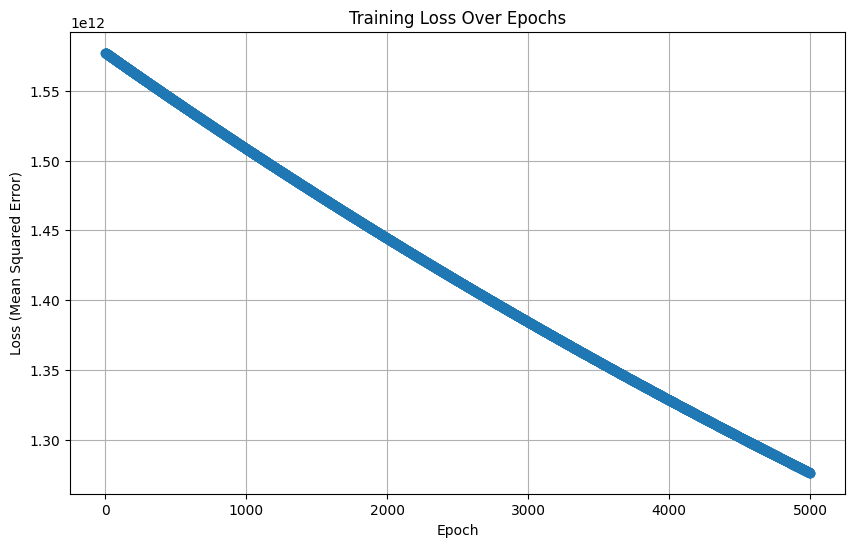

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_history)), loss_history, marker='o', linestyle='-')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.grid(True)
plt.show()

In [36]:
y_pred = model.predict(X_test_final)

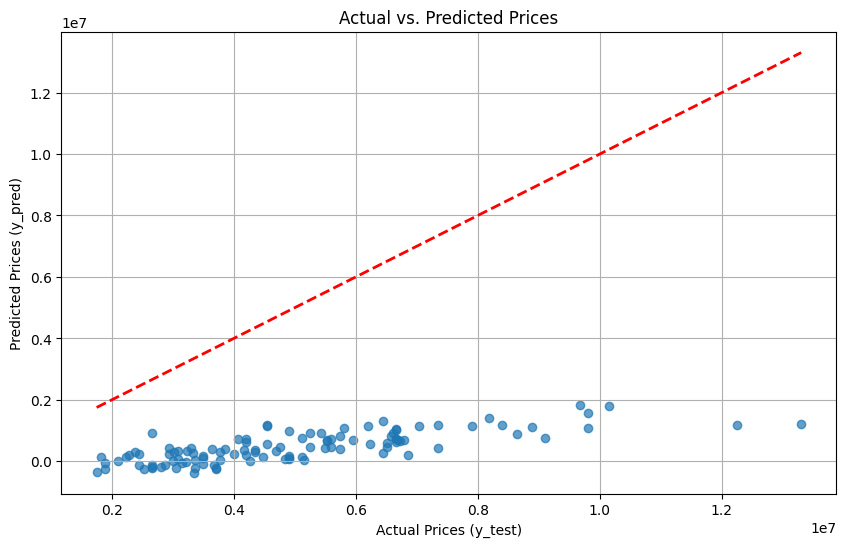

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Prices (y_test)')
plt.ylabel('Predicted Prices (y_pred)')
plt.grid(True)
plt.show()

In [38]:
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

R2 Score: -3.7929138607522033
